<a href="https://colab.research.google.com/github/SandAhmed/Team-Megaforce-Ai-project/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

In [90]:
df = pd.read_csv('train_data.csv')

In [91]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
299,LP001367,Male,Yes,1,Graduate,No,3052,1030.0,100.0,360.0,1.0,Urban,Y
300,LP001606,Male,Yes,0,Graduate,No,3497,1964.0,116.0,360.0,1.0,Rural,Y
301,LP002366,Male,Yes,0,Graduate,No,2666,4300.0,121.0,360.0,1.0,Rural,Y
302,LP002777,Male,Yes,0,Graduate,No,2785,2016.0,110.0,360.0,1.0,Rural,Y
303,LP001579,Male,No,0,Graduate,No,2237,0.0,63.0,480.0,0.0,Semiurban,N


In [92]:
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [93]:
#null values percentage
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               0.986842
Married              0.000000
Dependents           2.302632
Education            0.000000
Self_Employed        5.592105
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     2.960526
Credit_History       7.565789
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [114]:


df['Dependents'] =df['Dependents'].fillna(df['Dependents'].mode()[0])
#df['Gender'].fillna(df['Gender'].mode()[0], inplace=True, errors = 'ignore')
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])


In [95]:
, inplace=Truele = LabelEncoder()
categ_cols = [ 'Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Gender                   str
Married                int64
Dependents               str
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [96]:
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            304 non-null    int64  
 1   Gender             301 non-null    str    
 2   Married            304 non-null    int64  
 3   Dependents         297 non-null    str    
 4   Education          304 non-null    int64  
 5   Self_Employed      304 non-null    int64  
 6   ApplicantIncome    304 non-null    int64  
 7   CoapplicantIncome  304 non-null    float64
 8   LoanAmount         304 non-null    float64
 9   Loan_Amount_Term   304 non-null    float64
 10  Credit_History     304 non-null    float64
 11  Property_Area      304 non-null    int64  
 12  Loan_Status        304 non-null    int64  
dtypes: float64(4), int64(7), str(2)
memory usage: 31.0 KB


In [98]:
df.describe()

,Loan_ID,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,304.00000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,151.50000,0.605263,0.269737,0.194079,3583.828947,1220.645132,105.282895,342.631579,0.835526,1.036184,0.707237
std,87.90146,0.489600,0.444555,0.518787,1366.102888,1732.098606,28.696412,66.256595,0.371316,0.780543,0.455781
min,0.00000,0.000000,0.000000,0.000000,210.000000,0.000000,17.000000,12.000000,0.000000,0.000000,0.000000
25%,75.75000,0.000000,0.000000,0.000000,2651.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000
50%,151.50000,1.000000,0.000000,0.000000,3365.500000,953.000000,110.500000,360.000000,1.000000,1.000000,1.000000
75%,227.25000,1.000000,1.000000,0.000000,4284.250000,2045.000000,128.000000,360.000000,1.000000,2.000000,1.000000
max,303.00000,1.000000,1.000000,2.000000,9703.000000,20000.000000,150.000000,480.000000,1.000000,2.000000,1.000000


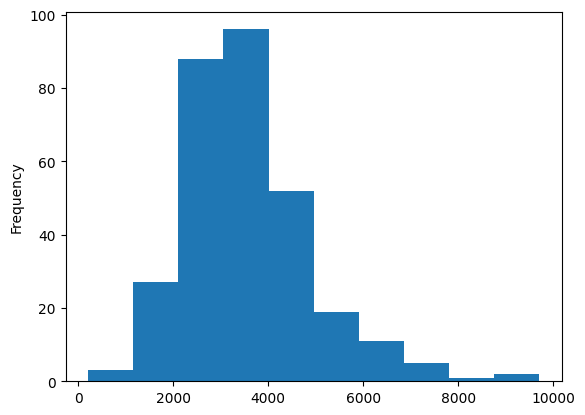

In [99]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

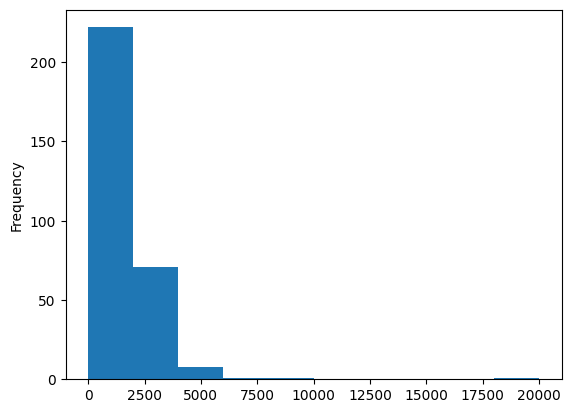

In [100]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [101]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

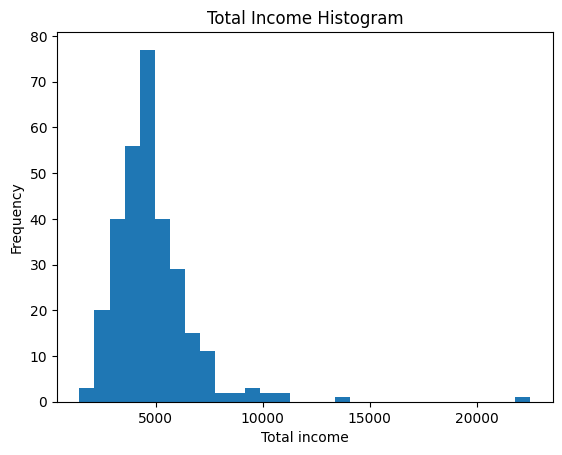

In [102]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

In [103]:
print(df.dtypes)

Loan_ID                int64
Gender                   str
Married                int64
Dependents               str
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


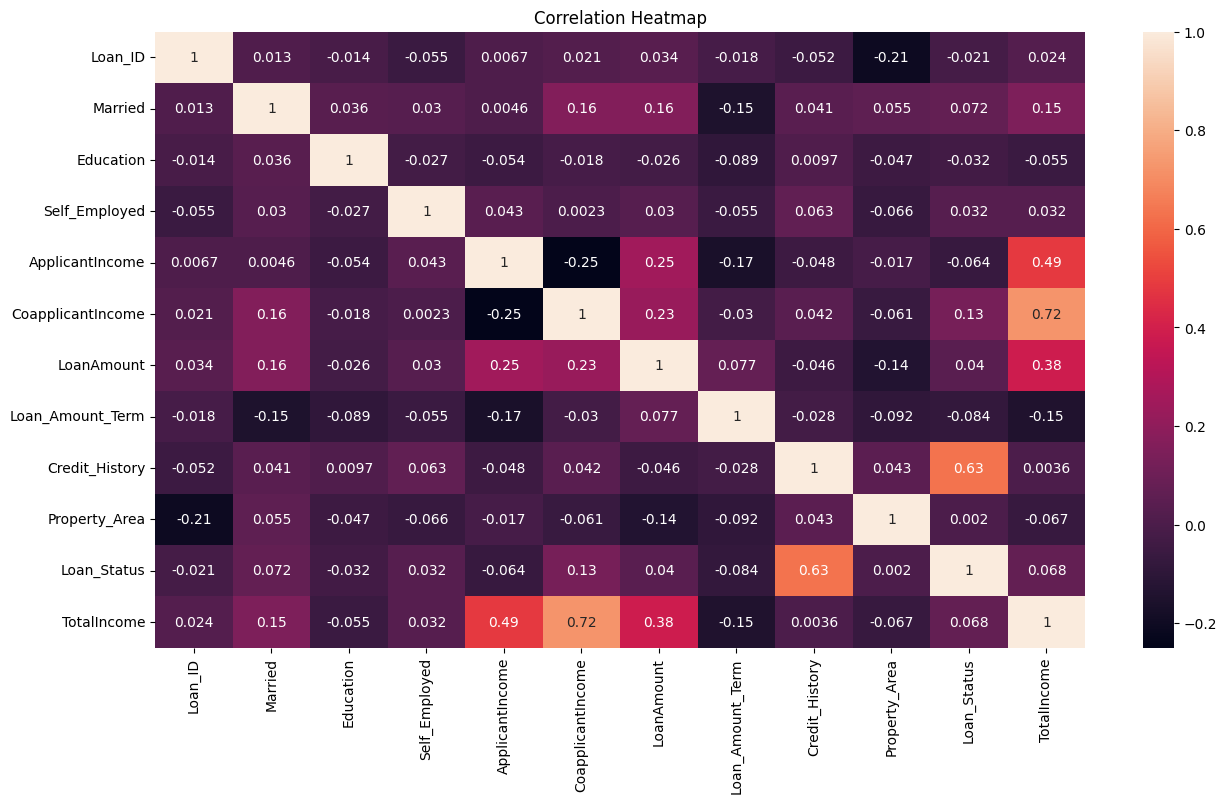

In [104]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [105]:
#dropped because the correlation coofecient between it and the loan status is low
df = df.drop('Gender',errors='ignore')

In [106]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
299,52,Male,1,1,0,0,3052,1030.0,100.0,360.0,1.0,2,1,4082.0
300,77,Male,1,0,0,0,3497,1964.0,116.0,360.0,1.0,0,1,5461.0
301,213,Male,1,0,0,0,2666,4300.0,121.0,360.0,1.0,0,1,6966.0
302,281,Male,1,0,0,0,2785,2016.0,110.0,360.0,1.0,0,1,4801.0
303,74,Male,0,0,0,0,2237,0.0,63.0,480.0,0.0,1,0,2237.0


In [107]:
features = ['Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term',]

In [108]:
x = df[features]
y = df['Loan_Status']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [115]:
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)

In [ ]:
df_no_duplicate =df.drop_duplicates()

In [ ]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(x_train, y_train)